<a href="https://colab.research.google.com/github/dannroldan/Procesos-estocasticos/blob/main/tutorial_SymPy_y_NetworkX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tutorial: SymPy y NetworkX**

## Fundamentos de Matrices en SymPy
Una matriz $A \in \mathbb{R}^{m \times n}$ se define simbólicamente. Podemos incluir variables como $\alpha$ o $\beta$ y trabajar con fracciones exactas usando `Rational(n, d)`.

### Operaciones Definidas:
* **Producto Matriz-Vector:** $\mathbf{y} = A\mathbf{x} \implies y_i = \sum_{j=1}^{n} a_{ij}x_j$
* **Potencia de Matriz:** $A^k = {A \cdot A \cdot \dots \cdot A}_{k \text{ veces}}$
* **Ecuación de Eigenvalores:** $\det(A - \lambda I) = 0$

Antes, para que las matrices y expresiones simbólicas se muestren con notación matemática
(en lugar de listas de Python), SymPy permite activar un modo de impresión
bonita.

Para activar este formato utilizamos la función:

$$
\texttt{init_printing()}
$$

la cual hace que SymPy renderice automáticamente matrices y expresiones en
formato $Latex$ dentro del notebook.

### Representación de una matriz

Una matriz $ A \in \mathbb{R}^{2 \times 2} \$ puede escribirse como:

\
$A =
\begin{pmatrix}
1 & 2 \\
3 & 4
\end{pmatrix}$


donde:
- ( $a_{ij}$ ) representa la entrada en el renglón \( i \) y columna \( j \).
- En programación, los índices comienzan en 0.

In [55]:
import sympy as sp
from sympy import Matrix, symbols, Rational, init_printing

# lo q mejora la visualización de salida en Colab
init_printing(use_latex='mathjax')

# definir variables simbólicas
a, b = symbols('a b')

# creamos una matriz con una mezcla de símbolos, enteros y fracciones
AA = Matrix([
    [a, 2, 1],
    [0, Rational(1, 3), b],
    [-1, 0, 5]
])


print("Matriz AA:")
display(AA)

# creamos una matriz numérica

print("\nMatriz A:")
A = sp.Matrix([[1, 2],
               [3, 4]])

A

Matriz AA:


⎡a    2   1⎤
⎢          ⎥
⎢0   1/3  b⎥
⎢          ⎥
⎣-1   0   5⎦


Matriz A:


⎡1  2⎤
⎢    ⎥
⎣3  4⎦

In [56]:
# obtener entradas
fila_1 = AA.row(1)          # 2da fila
col_2 = AA.col(2)           # 3ra columna
entrada_especifica = AA[0, 2] # fila 0, col 2

print(f"Entrada (0,2): {entrada_especifica}")

Entrada (0,2): 1


### Multiplicación de matrices

Sean:

$\quad
A =
\begin{pmatrix}
1 & 2 \\
3 & 4
\end{pmatrix}$

$\quad
B =
\begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix}$

El producto matricial se define como:

$
(AB)_{ij} = \sum_{k=1}^{n} a_{ik} b_{kj}
$

Recordar que:

$
AB \neq BA
$

In [57]:
B = sp.Matrix([[0, 1],
               [1, 0]])

A * B

⎡2  1⎤
⎢    ⎥
⎣4  3⎦

## Transformaciones Lineales

Para una matriz cuadrada $M$, los **vectores propios** ($\vec{v}$) y **valores propios** ($\lambda$) satisfacen la condición:
$$M\vec{v} = \lambda\vec{v}$$

En SymPy, el método `.eigenvects()` descompone la matriz y retorna:
1. El **Valor Propio** ($\lambda$).
2. La **Multiplicidad algebraica**.
3. El **Espacio propio** (Base de vectores propios).

Además la potencia de una matriz se calcula mediante la diagonalización $M^k = P D^k P^{-1}$.

In [58]:
# definimos una matriz numérica para el análisis
M = Matrix([[4, -2], [1, 1]])

# multiplicación por vector
v = Matrix([3, 1])
prod = M * v

# potencia de una matriz
# calculamos M^k de forma simbólica (usando un símbolo 'k')
k = symbols('k', integer=True)
M_pot = M**3  # potencia fija


print("Multiplicación por vector")
display(prod)

Multiplicación por vector


⎡10⎤
⎢  ⎥
⎣4 ⎦

In [59]:
# valores y vectores propios
eigen_data = M.eigenvects()

print("Vectores Propios (λ, mult, [v]):")
display(eigen_data)

Vectores Propios (λ, mult, [v]):


⎡⎛      ⎡⎡1⎤⎤⎞  ⎛      ⎡⎡2⎤⎤⎞⎤
⎢⎜2, 1, ⎢⎢ ⎥⎥⎟, ⎜3, 1, ⎢⎢ ⎥⎥⎟⎥
⎣⎝      ⎣⎣1⎦⎦⎠  ⎝      ⎣⎣1⎦⎦⎠⎦

##Diagramas de Transición (NetworkX)
Un diagrama de transición representa una **Matriz Estocástica** $P$. Si estamos en el estado $i$, la probabilidad de saltar al estado $j$ es $P_{ij}$.

Visualmente, esto es un gráfico donde:
* **Nodos:** Representan los estados $S = \{s_1, s_2, \dots, s_n\}$.
* **Aristas:** Representan las transiciones.
* **Pesos:** Son las probabilidades $p \in [0, 1]$.

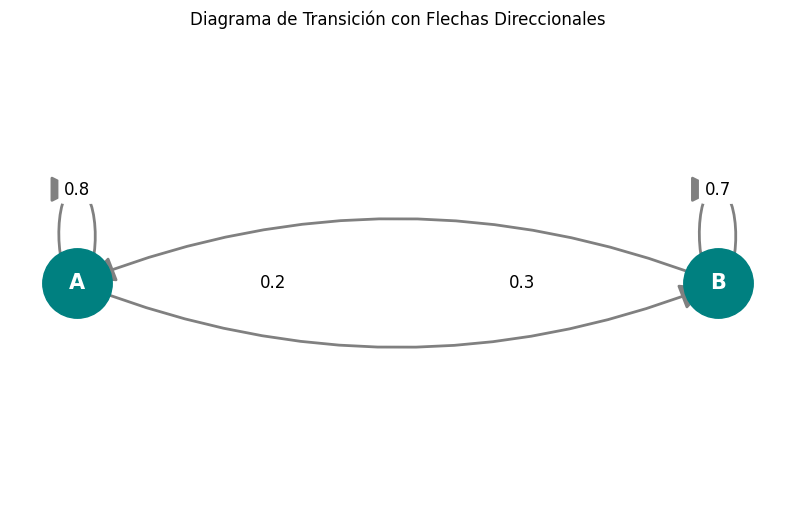

In [60]:
import networkx as nx
import matplotlib.pyplot as plt

# definir el grafo
G = nx.DiGraph()

# definir transiciones (estado inicial, estado finasl, prob)
# se incluyen los 'self-loops' (A -> A y B -> B)
edges = [
    ('A', 'A', 0.8), ('A', 'B', 0.2),
    ('B', 'A', 0.3), ('B', 'B', 0.7)
]

for u, v, w in edges:
    G.add_edge(u, v, weight=w)

# configuración de posición manual para q no se encimen
pos = {'A': (0, 0), 'B': (2, 0)}

plt.figure(figsize=(10, 6))

# dibujar Nodos
nx.draw_networkx_nodes(G, pos, node_size=2500, node_color='#008080')
nx.draw_networkx_labels(G, pos, font_color='white', font_size=15, font_weight='bold')


# arrowstyle: define la forma de la punta
# arrowsize: aumenta el tamaño de la flecha para que no la tape el nodo
# connectionstyle: crea la curva para que las flechas de ida y vuelta no choquen
nx.draw_networkx_edges(
    G, pos,
    arrowstyle='-|>',
    arrowsize=40,
    edge_color='gray',
    width=2,
    connectionstyle='arc3, rad=0.2'
)

# dibuja las etiquetas de las flechas (probabilidades)
edge_labels = nx.get_edge_attributes(G, 'weight')

# label_pos=0.3 mueve el texto más cerca del origen de la flecha para identificarla mejor
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=12, label_pos=0.3)

plt.title("Diagrama de Transición con Flechas Direccionales", pad=20)
plt.axis('off')
plt.show()